<a href="https://colab.research.google.com/github/Structsagar/NN_Sin_Denoising/blob/main/sin_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Reinforced Smoothing Neural Network**

###1. Importing Library

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import math


###2. Data Generation

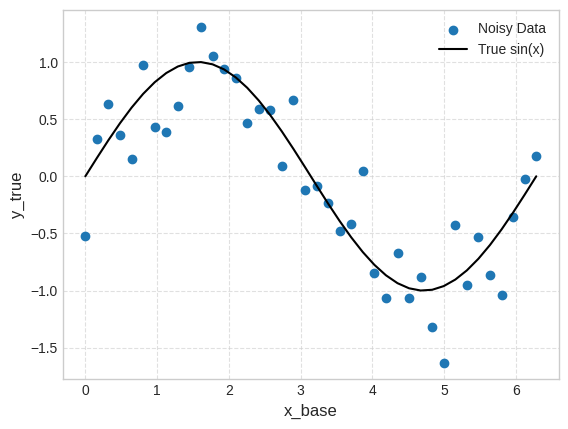

In [ ]:
N=40
x_base = torch.linspace(0,2 *torch.pi,N).reshape(-1,1)

#Ground Truth y = sin(x)
y_true = torch.sin(x_base)


torch.manual_seed(50)

#Gaussian Noise with Mean = 0 and Variance = 0.2
noise = torch.normal(0,math.sqrt(0.2),y_true.shape)
y_noise = y_true + noise  # Adding noise to True value

#Visualization of noisy data and True value
plt.figure()
plt.scatter(x_base, y_noise, label="Noisy Data") #Noise Scatter Plot
plt.plot(x_base, y_true, color = 'black', label="True sin(x)") # True data Plot

plt.xlabel("x_base", fontsize=12)
plt.ylabel("y_true", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

###Building Neural Network Architecture


*   One input | Two Hidden Layer | One Output

*   Non-Linear Activation FUnction : Tanh --> Since the ground truth sin(x) have both positive and negative values, for which the tanh is ideal, as its output range is (-1,1). Additionally, Tanh is infinitely differentiable. This is the requirement for the custom loss function, which relies on the second-order derivative (curvature) to enforce smoothness

* Forward function for prediction



In [ ]:
class NeuralNetwork(nn.Module):

  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

  def forward(self, x):
      return self.network(x)




### Loss Computation
1.   **Smooth_Loss**: This function calculates the second-order derivative of the network's output with respect to the input. By minimizing the mean squared curvature ($d^2y/dx^2$), it discourage high-frequency oscillations caused by noise.

$$Loss = \text{MSE} + \lambda \cdot \text{Smoothness}$$

2.   **custom_loss**: This is the primary objective function. It combines standard Mean Squared Error (MSE) with smoothness penalty, weighted by the hyperparameter $\lambda$ (lyambda), for reducing the overfitting and following the trend  with smooth regularization.


In [ ]:
def smooth_loss(x,y_pred):

  #Computing the first order derivative--> Penalizing Slope
  dy_dx = torch.autograd.grad(y_pred, x,
                              grad_outputs=torch.ones_like(y_pred),
                              create_graph=True)[0]

  #Computing the second order derivative--> Penalizing Curvature
  d2y_dx2 = torch.autograd.grad(dy_dx, x,
                                grad_outputs=torch.ones_like(dy_dx),
                                create_graph=True)[0]
  return torch.mean(d2y_dx2**2)



def custom_loss(x, y_pred,y_actual, lyambda):

  MSE = torch.mean((y_actual-y_pred)**2)    #Mean Squared Error
  loss = MSE + lyambda*smooth_loss(x,y_pred) #Combined loss

  return loss






###Hyperparameters

In [ ]:
epochs = 2000           #epoch
lr = 0.01               #learning rate
lyambda = [0.02, 0.0]   #smoothing rate

###Training Loop:

*   Created an object"model" for a class"Neural Network"
*   **Optimizer used** : Adam optimizer for convergence
* Loop iterates for N "epochs" times which includes forward pass for prediction and backward pass for computing and updating the optimized weights and biases





In [ ]:
models = []                                               #List to store trained models for each lambda
predictions = []                                          #List to store prediction from each model

for lam in lyambda:

  print(f"\nTraining model with lambda = {lam}")

  model = NeuralNetwork()                                 #Model Generation
  optim_func = torch.optim.Adam(model.parameters(),lr)    # Optimizer

  for epoch in range(1, epochs + 1):
        x = x_base.clone().detach().requires_grad_(True)  #Create a fresh input
                                                          #tensor with gradients

        optim_func.zero_grad()                            #resets the gradient to zero for each epoch to
                                                          #avoid the accumulation of gradients

        y_pred = model(x)                                 #forward pass

        loss = custom_loss(x, y_pred, y_noise, lam)       #compute loss with regularization

        loss.backward()                                   #backward propagation: Compute Gradients
        optim_func.step()                                 #Update model weights

        if epoch % (epochs/10) == 0:
          print(f"Epoch:{epoch}, Loss : {loss} \n")


  models.append(model)                                    #saving trained model for each lyambda

  with torch.no_grad():                                   #disable gradient tracking for evaluation
    y_pred = model(x).detach().numpy()  #
    predictions.append(y_pred)                            #storing prediction for each lyambda




Training model with lambda = 0.02
Epoch:200, Loss : 0.09293331205844879 

Epoch:400, Loss : 0.09131472557783127 

Epoch:600, Loss : 0.09106769412755966 

Epoch:800, Loss : 0.09124249964952469 

Epoch:1000, Loss : 0.09111103415489197 

Epoch:1200, Loss : 0.09104117006063461 

Epoch:1400, Loss : 0.0910436287522316 

Epoch:1600, Loss : 0.0911087840795517 

Epoch:1800, Loss : 0.0909779891371727 

Epoch:2000, Loss : 0.09095975011587143 


Training model with lambda = 0.0
Epoch:200, Loss : 0.07960741221904755 

Epoch:400, Loss : 0.06295329332351685 

Epoch:600, Loss : 0.061441220343112946 

Epoch:800, Loss : 0.05957704782485962 

Epoch:1000, Loss : 0.06202296167612076 

Epoch:1200, Loss : 0.056451357901096344 

Epoch:1400, Loss : 0.050898194313049316 

Epoch:1600, Loss : 0.040451664477586746 

Epoch:1800, Loss : 0.027419302612543106 

Epoch:2000, Loss : 0.017917726188898087 



###Tensor to Numpy for Plot

In [ ]:
x_plot = x_base.numpy()
y_true_plot = y_true.numpy()
y_noise_plot = y_noise.numpy()

y_pred_plot_smooth = predictions[0]
y_pred_plot_mse = predictions[1]


###PLOT:


*   **Plot** reveals that the Neural network with only MSE function overfits the noisy data with the loss of 1.79%. However, penalizing the curvature with the lambda = 0.02 (i.e, introducing the smooth loss), the neural network sucessfully predicted the approximate sinx curve without overfitting.

* Loss evaluation in above cell depicts, the loss increases with the inclusion of the smoothness function which gives insight of moving away from the actual noise data.

*   **Findings**: Denoising the input acceleration using Neural Network in the structure while preprecessing, it is necessary to penalize the curvature loss. If not, the neural network overfits the data and give unrealistic response of the structure while post processing in finite element analysis.



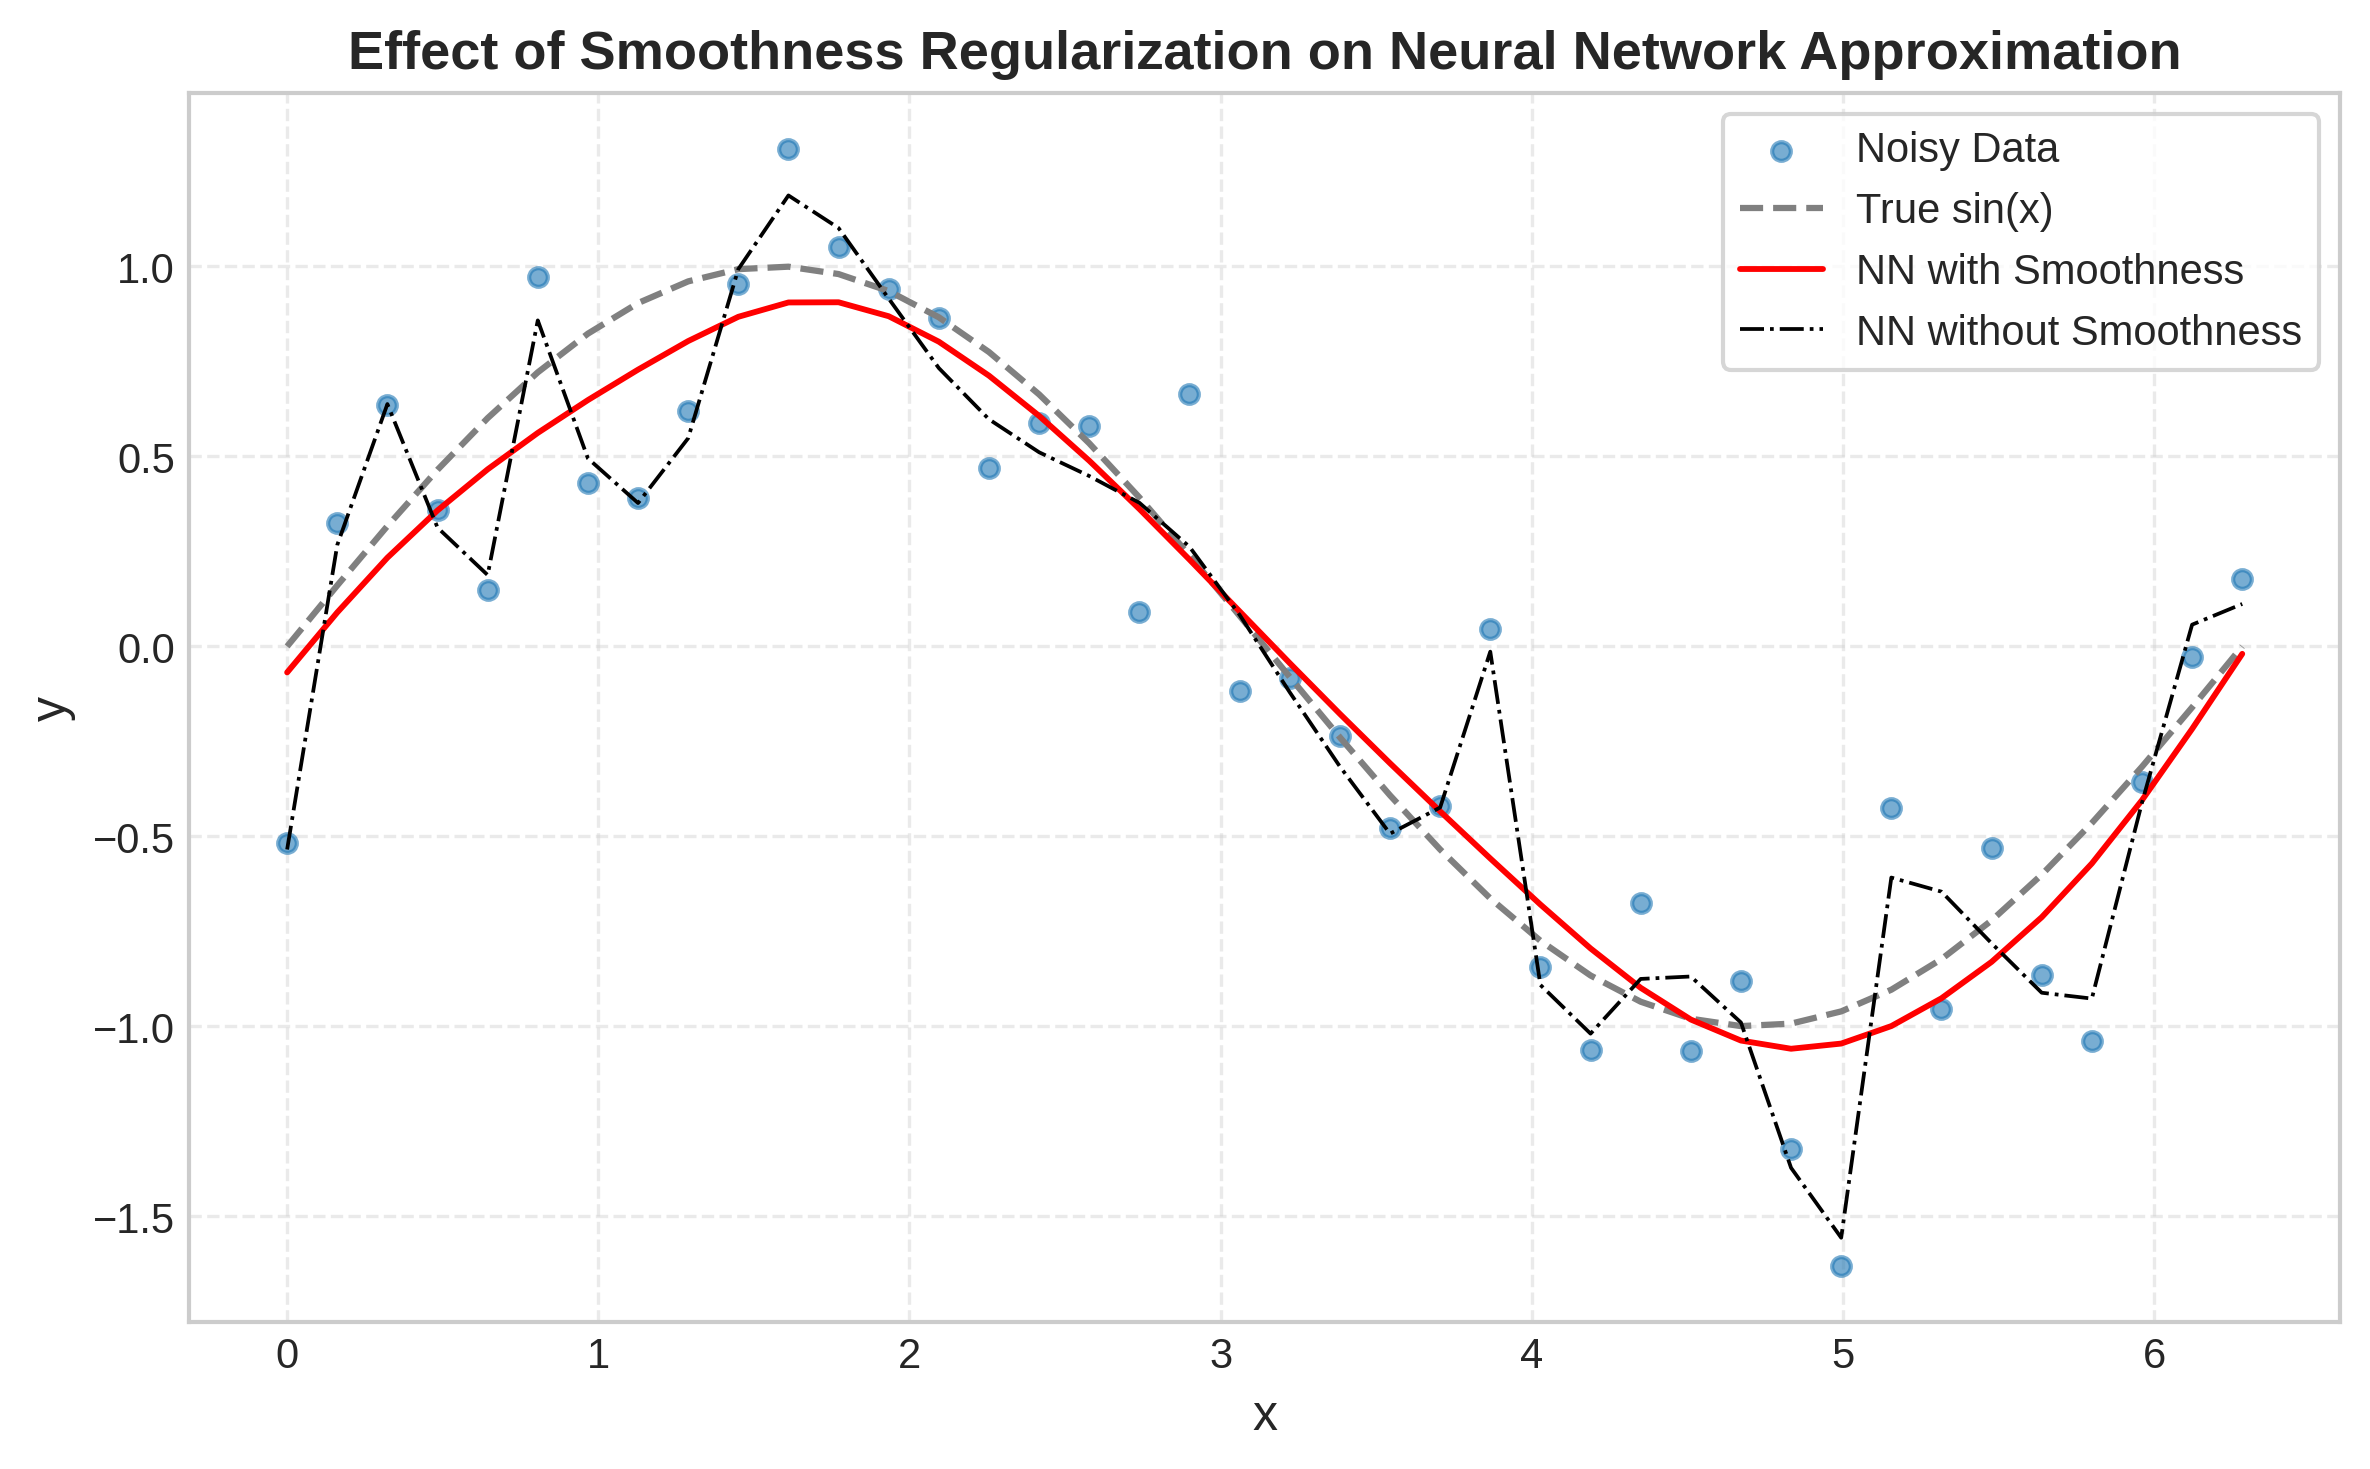

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(8, 5), dpi=300)

# Noisy data
plt.scatter(x_plot, y_noise_plot,
            label="Noisy Data",
            alpha=0.6,
            s=20)

# True data
plt.plot(x_plot, y_true_plot,
         linestyle='--',
         linewidth=1.5,
         color='grey',
         label="True sin(x)")

# Smooth model prediction
plt.plot(x_plot, y_pred_plot_smooth,
         linewidth=1.4,
         color='red',
         label="NN with Smoothness")

#Without smooth model prediction
plt.plot(x_plot, y_pred_plot_mse,
         linewidth=0.9,
         linestyle='-.',
         color='black',
         label="NN without Smoothness")

# Labels
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)

# Title
plt.title("Effect of Smoothness Regularization on Neural Network Approximation",
          fontsize=13, weight='bold')

plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

## **CURVATURE SENSITIVITY ANALYSIS ON MODEL**

For clear intuition, I further tested the neural network by varying lyambdas(penalizing factor) from higher to lower. The following conclusion were abstracted:


*   ## Effect of Smoothness Parameter (λ)

- Large λ (0.2):
  - Produces overly smooth predictions
  - Fails to capture true function → Underfitting

- Moderate λ (0.02, 0.002):
  - Good balance between smoothness and accuracy
  - Best approximation of true sin(x)

- Small λ (0.0002, 0.0):
  - Fits noisy data closely
  - Introduces oscillations → Overfitting

## Loss Comparison

- Smaller λ achieves lower loss but overfits noise
- Larger λ increases loss due to smoothness constraint
- Optimal λ provides stable convergence and better generalization

## Conclusion

An intermediate λ (≈ 0.002–0.02) provides the best trade-off between data fitting and smoothness, avoiding both underfitting and overfitting.




In [ ]:
lyambdas = [0.2, 0.02, 0.002, 0.0002, 0.0]

predictions = []
models = []
Loss = []

for lam in lyambdas:
    print(f"\nTraining model with lambda = {lam}")

    model = NeuralNetwork()
    optimizer = torch.optim.Adam(model.parameters(), lr)
    loss_acc = []  # storing losses for each model

    for epoch in range(1, epochs + 1):
        x = x_base.clone().detach().requires_grad_(True)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = custom_loss(x, y_pred, y_noise, lam)
        loss_acc.append(loss.item())

        loss.backward()
        optimizer.step()

    models.append(model)
    Loss.append(loss_acc)

    with torch.no_grad():
        y_pred_plot = model(x_base).detach().numpy()
        predictions.append(y_pred_plot)



Training model with lambda = 0.2

Training model with lambda = 0.02

Training model with lambda = 0.002

Training model with lambda = 0.0002

Training model with lambda = 0.0


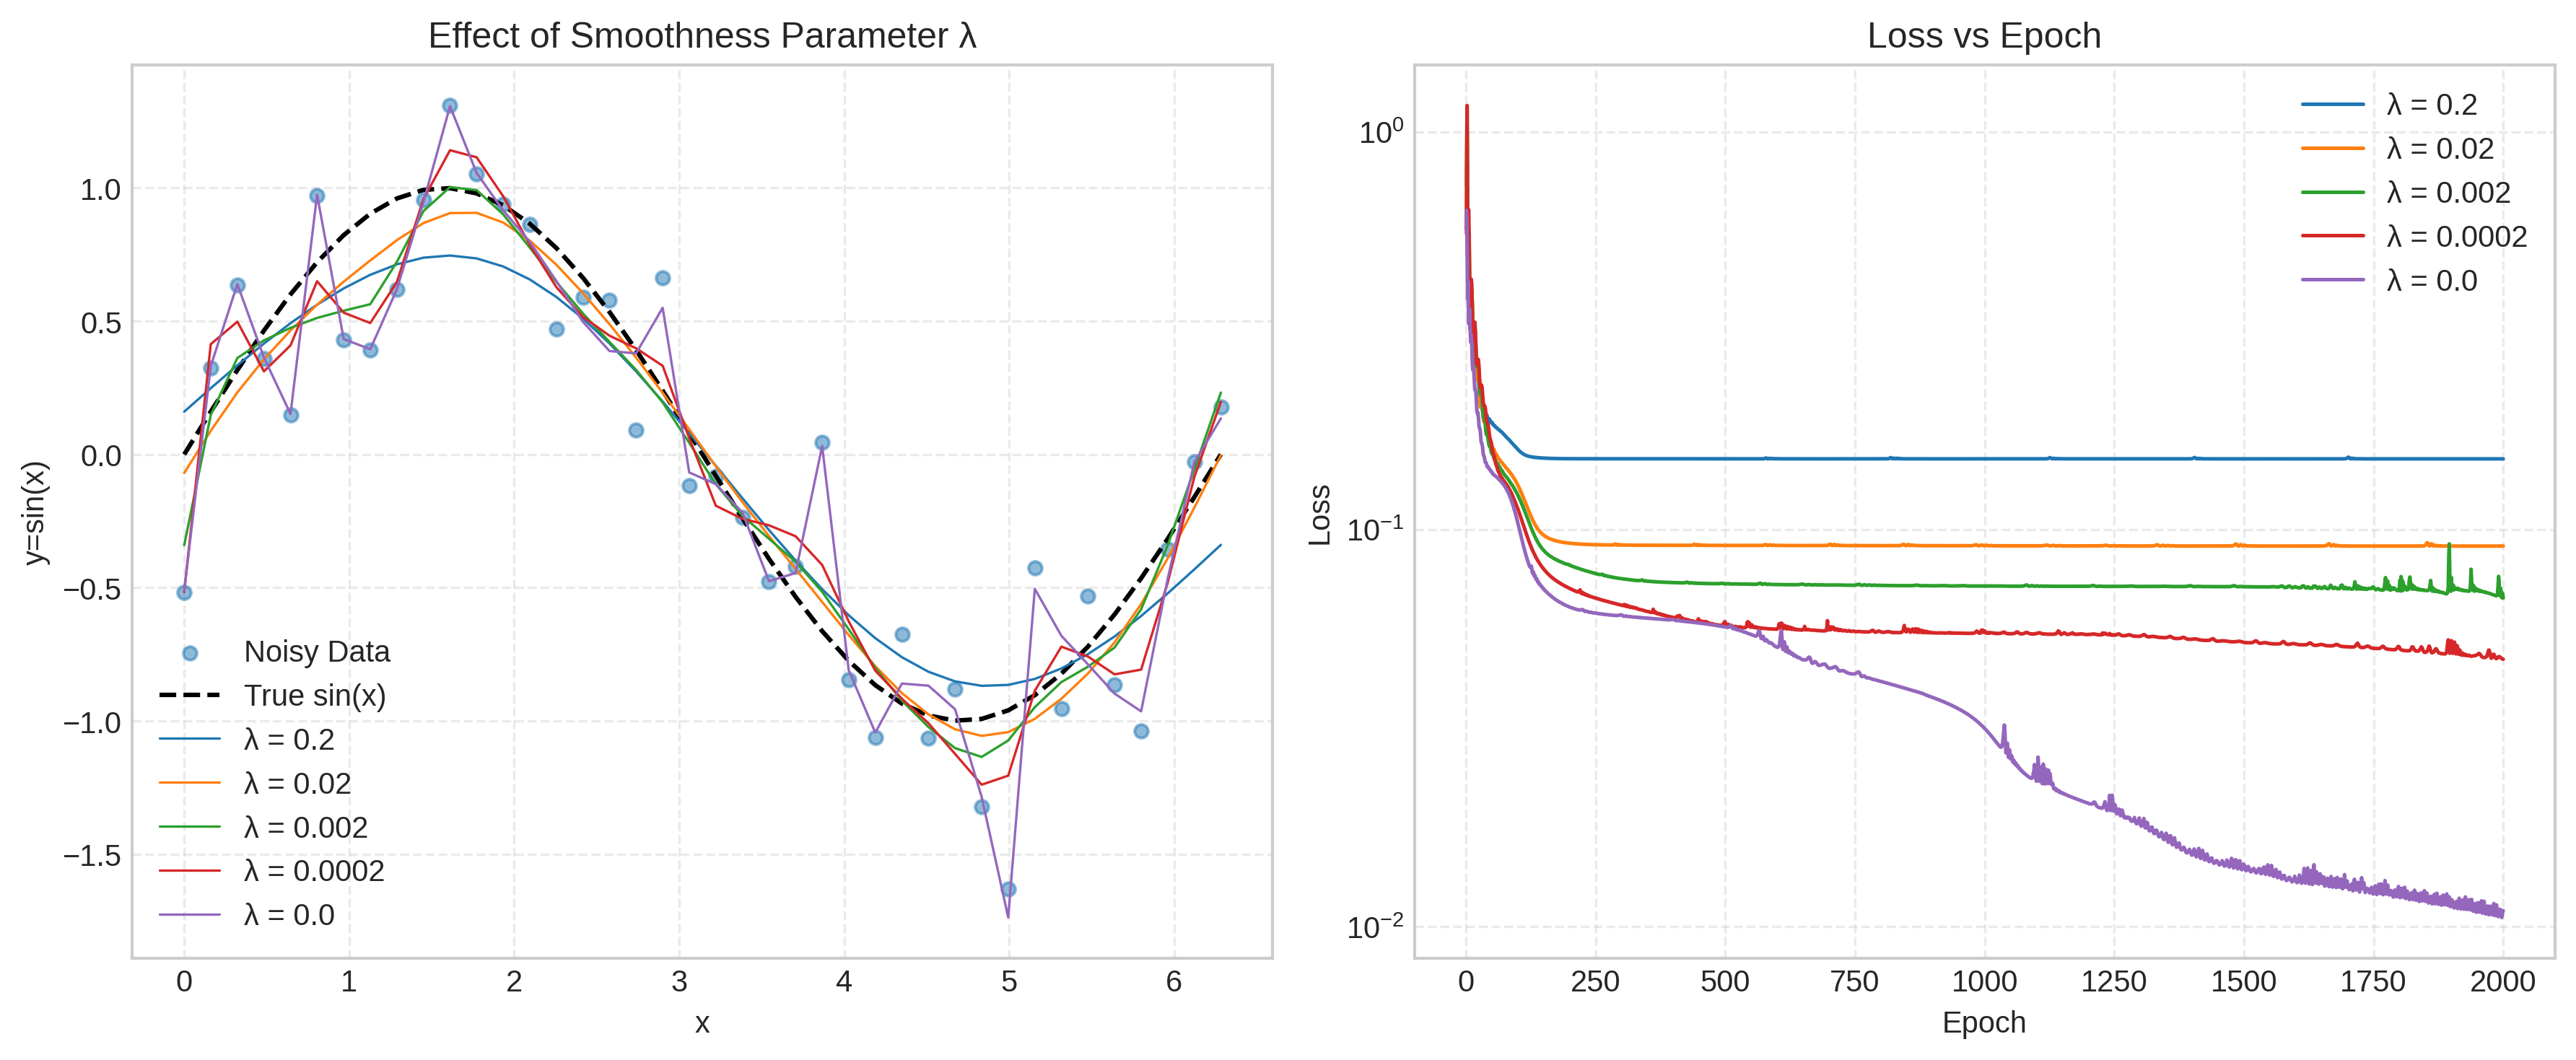

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

ax = axes[0] # left plot

# Noisy data
ax.scatter(x_plot, y_noise_plot,
           s=20, alpha=0.5, label="Noisy Data")

# True function
ax.plot(x_plot, y_true_plot,
        linestyle='--', color='black',
        linewidth=1.5, label="True sin(x)")

# Plot loop for all lambda predictions
for i, lam in enumerate(lyambdas):
    ax.plot(x_plot, predictions[i],
            linewidth=0.8,
            label=f"λ = {lam}")

ax.set_xlabel("x")
ax.set_ylabel("y=sin(x)")
ax.set_title("Effect of Smoothness Parameter λ")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)


ax = axes[1]  #Right Plot

epoch = np.arange(1, epochs + 1)

for i, lam in enumerate(lyambdas):
    ax.plot(epoch, Loss[i],
            linewidth=1.2,
            label=f"λ = {lam}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss vs Epoch")
ax.set_yscale('log')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()